## Creating Advanced Rasterized Geodata with Multiple Cost Layers for Distribution Grid Planning

### Overview
This comprehensive script demonstrates how to prepare advanced rasterized geodata using multiple
data sources and cost assumptions for infrastructure planning. The process includes
downloading vector data, applying buffers to infrastructure, incorporating protected
areas, and creating multi-layered cost rasters.

### Key Features:
- Integration of multiple geospatial data layers
- Dynamic cost assumption modeling
- Environmental and regulatory constraint handling
- Optimal path finding for infrastructure planning

### Data Source
The datasets used in this script (and additional resources) are provided by the 
[Hessian Agency for Nature Conservation, Environment and Geology (HLNUG)](https://www.hlnug.de/).

### Quick Start Note
For users seeking immediate access to pyorps route planning functionality without configuring detailed cost assumptions, Section 7 demonstrates a simplified all-in-one
 approach. However, we highly recommend reviewing the complete workflow, as cost assumptions have a profound impact on routing results, potentially changing both the selected path and total project costs significantly. Understanding these parameters will help you tailor the analysis to your infrastructure planning requirements.


### 1. Import Required Libraries and Functions

We'll import the necessary components from the `pyorps` package, which provides 
specialized tools for geospatial rasterization and path finding operations.

In [1]:
import os
from pyorps import (initialize_geo_dataset, save_empty_cost_assumptions, PathFinder,
                    GeoRasterizer, detect_feature_columns, CostAssumptions)

### 2. Define Study Area, the Base Dataset, and Its Cost Assumptions

In this section, we'll establish the geographical boundaries of our study area and 
configure the base land-use dataset that will serve as the foundation for our cost analysis.

#### 2.1 Define the Bounding Box for the Study Area

The bounding box defines the geographical extent of our analysis area.
- **Format**: (minx, miny, maxx, maxy) 
- **Coordinate System**: EPSG:25832 (ETRS89 / UTM zone 32N)
- **Coverage**: Approximately 30km x 20km area in Hessen, Germany

In [2]:
bbox_tuple = (460000, 5590000, 490000, 5610000)

#### 2.2 Define WFS Request for the Base Dataset

We'll connect to the official WFS (Web Feature Service) to retrieve land-use data 
from the ALKIS (Amtliches Liegenschaftskataster-Informationssystem) database.

In [3]:
base_wfs_request = {
    "url": "https://www.gds.hessen.de/wfs2/aaa-suite/cgi-bin/alkis/vereinf/wfs",
    "layer": "ave_Nutzung"
}

#### 2.3 Initialize and Load Base Dataset

Now we'll initialize the geodataset with our WFS request and load the data for our
specified bounding box.

Initialize the geodataset with the WFS request and bounding box parameters

In [4]:
base_land_use_dataset = initialize_geo_dataset(base_wfs_request, bbox=bbox_tuple)

Load the actual data from the WFS service for the specified area

In [5]:
base_land_use_dataset.load_data()

In [6]:
print("="*60)
print("✅ BASE LAND-USE DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"📊 Dataset shape: {base_land_use_dataset.data.shape[0]:,} features × {base_land_use_dataset.data.shape[1]} attributes")
print(f"📍 Bounding box: {bbox_tuple}")
print("="*60)

✅ BASE LAND-USE DATASET LOADED SUCCESSFULLY
📊 Dataset shape: 71,946 features × 7 attributes
📍 Bounding box: (460000, 5590000, 490000, 5610000)


#### 2.4 Identify Feature Columns in the Given Land-Use Dataset, Suited for Defining Cost Assumptions

We need to identify which columns in our dataset are most suitable for defining cost 
assumptions. The `detect_feature_columns` function automatically analyzes the data to 
suggest the best columns for categorization.

In [7]:
print("\n" + "="*60)
print("📋 COLUMN ANALYSIS")
print("="*60)
print(f"Available columns in dataset:")
for i, col in enumerate(base_land_use_dataset.data.columns, 1):
    print(f"  {i:2d}. {col}")
print("-"*60)


📋 COLUMN ANALYSIS
Available columns in dataset:
   1. gml_id
   2. oid
   3. aktualit
   4. nutzart
   5. name
   6. bez
   7. geometry
------------------------------------------------------------


Automatically detect the most suitable columns for cost categorization

In [8]:
main_feature, side_features = detect_feature_columns(base_land_use_dataset.data,
                                                     max_features_per_column=100)

In [9]:
print("\n🔍 Suggested feature columns for cost assignment:")
print(f"  • Main feature: '{main_feature}'")
print(f"  • Side features: {side_features}")
print("="*60)


🔍 Suggested feature columns for cost assignment:
  • Main feature: 'nutzart'
  • Side features: ['bez']


#### 2.5 Save CSV Template for Defining the Cost Assumptions for the Land-Use Dataset

We'll create a template CSV file that can be used to manually define cost assumptions 
for each land-use category. This step creates the necessary directory structure and 
generates a blank template.

Create directory for cost assumptions if it doesn't exist

In [10]:
os.makedirs("./data/cost_assumptions", exist_ok=True)

Generate an empty cost assumptions template for the base land-use data. This step is 
optional but useful for documentation and future modifications.

In [11]:
template_path = "./data/cost_assumptions/base_land_use_template.csv"
save_empty_cost_assumptions(base_land_use_dataset,
                            save_path=template_path,
                            main_feature=main_feature,
                            side_features=side_features)

{('Straßenverkehr', ''): 0,
 ('Weg', ''): 0,
 ('Bahnverkehr', ''): 0,
 ('Landwirtschaft', 'Ackerland'): 0,
 ('Landwirtschaft', 'Grünland'): 0,
 ('Fließgewässer', 'Graben'): 0,
 ('Gehölz', ''): 0,
 ('Sumpf', ''): 0,
 ('Fließgewässer', 'Bach'): 0,
 ('Fläche gemischter Nutzung', ''): 0,
 ('Wald', 'Laubholz'): 0,
 ('Fläche besonderer funktionaler Prägung', ''): 0,
 ('Platz', 'Parkplatz'): 0,
 ('Wald', 'Nadelholz'): 0,
 ('Wald', 'Laub- und Nadelholz'): 0,
 ('Unland/Vegetationslose Fläche', ''): 0,
 ('Fließgewässer', 'Fluss'): 0,
 ('Wohnbaufläche', ''): 0,
 ('Fläche gemischter Nutzung',
  'Gebäude- und Freifläche Land- und Forstwirtschaft'): 0,
 ('Fläche gemischter Nutzung',
  'Gebäude- und Freifläche Mischnutzung mit Wohnen'): 0,
 ('Sport-, Freizeit- und Erholungsfläche', 'Grünanlage'): 0,
 ('Platz', ''): 0,
 ('Landwirtschaft', 'Gartenbauland'): 0,
 ('Stehendes Gewässer', 'Speicherbecken'): 0,
 ('Industrie- und Gewerbefläche', 'Handel und Dienstleistung'): 0,
 ('Industrie- und Gewerbefläche

#### 2.6 Define Cost Assumptions for the Land-Use Dataset

Here we define comprehensive cost assumptions for different land-use categories. These 
values represent the total construction costs (civil engineering + material costs) in €/m 
for laying distribution grid infrastructure.

##### Cost Value Guidelines:
- **Standard values**: 300-600 €/m for typical terrain
- **Difficult terrain**: 600-800 €/m (e.g., railway crossings)
- **Prohibited areas**: 65535 €/m (effectively blocking routing)

You can either fill the previously created `base_land_use_template.csv` file manually 
or use the following dictionary programmatically.

In [12]:
land_use_costs = {
    ('nutzart', 'bez'): {
        "Wald": {
            "Nadelholz": 405,
            "Laub- und Nadelholz": 425,
            "Laubholz": 475,
            "": 405},

        "Straßenverkehr": {
            "": 350
        },

        "Weg": {
            "Fußweg": 300,
            "Rad- und Fußweg": 300,
            "": 300
        },

        "Landwirtschaft": {
            "Ackerland": 437,
            "Grünland": 437,
            "Gartenbauland": 581,
            "Streuobstwiese": 581,
            "Obst- und Nussplantage": 581,
            "Streuobstacker": 468,
            "Baumschule": 581,
            "Brachland": 380,
            "": 437
        },

        "Fließgewässer": {
            "Graben": 332,
            "Bach": 346,
            "Kanal": 358,
            "Fluss": 586,
            "": 332
        },

        "Stehendes Gewässer": {
            "Teich": 350,
            "Speicherbecken": 590,
            "Stausee": 590,
            "Baggersee": 590,
            "": 400
        },

        "Sport-, Freizeit- und Erholungsfläche": {
            "Grünanlage": 320,
            "": 65535
        },
        "Gehölz": {
            "": 380
        },

        "Platz": {
            "Parkplatz": 310,
            "Rastplatz": 320,
            "": 310
        },

        "Flugverkehr": {
            "Segelfluggelände": 200,
            "Sonderlandeplatz": 300,
            "": 65535
        },

        "Bahnverkehr": {
            "": 800
        },

        "Heide": {
            "": 125
        },

        "Unland/Vegetationslose Fläche": {
            "": 125
        },

        "Fläche gemischter Nutzung": {"": 65535},
        "Fläche besonderer funktionaler Prägung": {"": 65535},
        "Wohnbaufläche": {"": 65535},
        "Sumpf": {"": 65535},
        "Industrie- und Gewerbefläche": {"": 65535},
        "Tagebau, Grube, Steinbruch": {"": 65535},
        "Friedhof": {"": 65535},
        "Moor": {"": 65535},
        "Halde": {"": 65535},
        "Schiffsverkehr": {"": 65535}
    }
}

#### 2.7 Rasterize Land-Use Dataset with Custom Cost Assumptions

Now we'll convert our vector land-use data into a raster format with cost values 
assigned to each pixel based on our defined assumptions.

##### 2.7.1 Create CostAssumptions Instance
You can create the CostAssumptions instance either from the dictionary or by loading 
a prepared CSV file.

**Note**: If using the CSV file approach, ensure the file has been filled with your 
cost assumptions before loading!

In [13]:
land_use_cost_assumptions = CostAssumptions(land_use_costs)

#land_use_cost_assumptions = CostAssumptions(template_path)

##### 2.7.2 Save Cost Assumptions to CSV
If you used the dictionary approach, it's recommended to save the cost assumptions 
to a CSV file for documentation and future reference.

Save the cost assumptions to a CSV file for documentation and reusability

In [14]:
land_use_cost_assumptions_path = "./data/cost_assumptions/base_landuse_cost_assumptions.csv"
land_use_cost_assumptions.to_csv(land_use_cost_assumptions_path)

In [15]:
print("\n" + "="*60)
print("💾 COST ASSUMPTIONS SAVED")
print("="*60)
print(f"📁 File location: {land_use_cost_assumptions_path}")
print(f"📊 Total cost categories defined: {len(land_use_costs[('nutzart', 'bez')])}")
print("="*60)


💾 COST ASSUMPTIONS SAVED
📁 File location: ./data/cost_assumptions/base_landuse_cost_assumptions.csv
📊 Total cost categories defined: 23


##### 2.7.3 Create GeoRasterizer Instance and Generate Cost Raster
This step creates the actual raster file where each pixel contains the cost value 
for infrastructure construction at that location.

Define the output path for the raster file

In [16]:
dgp_save_path = "./data/raster/raster_for_distribution_grid_planning.tiff"

Create GeoRasterizer instance with the dataset and cost assumptions

In [17]:
geo_rasterizer = GeoRasterizer(base_land_use_dataset, land_use_cost_assumptions)

Perform the rasterization and save the output

In [18]:
geo_rasterizer.rasterize(save_path=dgp_save_path)

### 3. Refine Land-Use Dataset and Cost Assumptions

In this section, we'll enhance our base dataset by adding more detailed classifications 
for street infrastructure and applying appropriate buffer zones.
#### 3.1 Define Helper Functions for Geometry Processing

##### 3.1.1 Street Classification and Buffer Function
This function differentiates between various types of street infrastructure according
to the German road classification system and applies appropriate buffer zones to account
for construction restrictions near major roads.

In [19]:
def set_street_type_and_buffer(gdf):
    """
    Classify street types and apply appropriate buffers based on German road classification.

    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame containing street data with 'nutzart' and 'name' columns

    Notes:
    ------
    - A roads (Autobahn): 20m buffer
    - B roads (Bundesstraße): 15m buffer
    - L roads (Landstraße): 10m buffer
    """
    all_streets = gdf['nutzart'] == 'Straßenverkehr'

    for prefix, road_type, buffer in zip(['A ', 'B ', 'L '],
                                         ["Autobahn", "Bundesstr.", "Landstr."],
                                         [10, 4, 2]):
        mask = all_streets & gdf['name'].str.contains(prefix, na=False)
        gdf.loc[mask, 'bez'] = road_type
        buffered = gdf.loc[mask, 'geometry'].buffer(buffer)
        gdf.loc[mask, 'geometry'] = buffered

##### 3.1.2 Update Cost Assumptions with Refined Street Categories
We'll update our cost assumptions to reflect the different construction costs 
associated with crossing or working near different types of roads.

In [20]:
land_use_costs[('nutzart', 'bez')].update({
            "Straßenverkehr": {
                "Landesstr.": 450,
                "Bundesstr.": 500,
                "Autobahn": 750,
                "": 340
            }
        }
)
land_use_cost_assumptions = CostAssumptions(land_use_costs)

##### 3.1.3 Update the Raster File with Refined Cost Assumptions
We'll regenerate the raster file with our updated cost assumptions to incorporate 
the refined street categories.

Define save path for the updated raster

In [21]:
dgp_save_path = "./data/raster/raster_for_distribution_grid_planning.tiff"

Create new GeoRasterizer with updated cost assumptions

In [22]:
geo_rasterizer = GeoRasterizer(base_land_use_dataset, land_use_cost_assumptions)

Regenerate the raster with refined street categories. Pass the defined function `set_street_type_and_buffer` as `preprocessing_function`!

**Note**: The following cell will create a file with 1.42 GB on your hard drive!

In [23]:
geo_rasterizer.rasterize(save_path=dgp_save_path, preprocessing_function=set_street_type_and_buffer)


### 4. Define Additional Datasets to Modify the Base Raster File

In this section, we'll incorporate additional environmental and regulatory constraints 
that affect construction costs. These include water protection zones, soil conditions, 
and nature protection areas.

For each additional dataset, we'll follow steps similar to sections 2.2 through 2.7.2 
to define appropriate cost modifications.

#### 4.1 Prepare Modification by Drinking Water Protection Zones

Water protection zones require special construction techniques and materials to prevent 
contamination, significantly affecting costs.

##### 4.1.1 Define WFS Request for Water Protection Zones

In [24]:
drinking_water_protection_wfs_request = {
    "url": "https://geodienste-umwelt.hessen.de/arcgis/services/inspire/bewirtschaftungsgebiete/MapServer/WFSServer",
    "layer": "TWS_HQS_TK25"
}

##### 4.1.2 Initialize and Load Water Protection Dataset

Initialize the water protection dataset with the WFS request

In [25]:
water_protection_dataset = initialize_geo_dataset(drinking_water_protection_wfs_request,
                                                  bbox=bbox_tuple)

Load the water protection zone data

In [26]:
water_protection_dataset.load_data()

In [27]:
print("\n" + "="*60)
print("💧 WATER PROTECTION DATASET LOADED")
print("="*60)
print(f"📊 Dataset shape: {water_protection_dataset.data.shape[0]:,} features × {water_protection_dataset.data.shape[1]} attributes")
print(f"📍 Coverage area: Same as base dataset")
print("="*60)


💧 WATER PROTECTION DATASET LOADED
📊 Dataset shape: 113 features × 25 attributes
📍 Coverage area: Same as base dataset


##### 4.1.3 Identify Feature Columns from Water Protection Dataset

**Note**: No side features are necessary for this dataset. We use fewer features per 
column as this dataset doesn't require extensive differentiation.

Detect the main feature column for water protection zones

In [28]:
main_feature_tws, _ = detect_feature_columns(water_protection_dataset.data,
                                             max_features_per_column=4)

In [29]:
print("\n" + "="*60)
print("🔍 WATER PROTECTION ZONE ANALYSIS")
print("="*60)
print(f"Suggested feature column: '{main_feature_tws}'")
print("\nZone distribution in dataset:")
print("-"*40)
for zone, count in water_protection_dataset.data[main_feature_tws].value_counts().items():
    print(f"  Zone {zone}: {count:,} features")
print("="*60)


🔍 WATER PROTECTION ZONE ANALYSIS
Suggested feature column: 'ZONE_KEY'

Zone distribution in dataset:
----------------------------------------
  Zone 3: 43 features
  Zone 2: 42 features
  Zone 1: 25 features
  Zone 4: 2 features
  Zone 22: 1 features


##### 4.1.4 Define Cost Multipliers for Water Protection Zones

Water protection zones require special considerations that multiply the base construction costs:

- **Zone 1**: Core protection area - Construction typically forbidden (×100)
- **Zone 2**: Inner protection area - Severe restrictions (×2)
- **Zone 3**: Outer protection area - Moderate restrictions (×1.5)
- **Zone 4**: Extended protection area - Minor restrictions (×1.2)

In [30]:
water_protection_multipliers = {
    main_feature_tws: {
        1: 100,     # Very high multiplication factor for "forbidden zones"
        2: 2,       # Double the cost for very restricted areas
        3: 1.5,     # Add 50% to the base land-use cost assumptions
        4: 1.2,
    }
}

##### 4.1.5 Create CostAssumptions Instance for Water Protection

In [31]:
water_protection_cost_assumptions = CostAssumptions(water_protection_multipliers)

##### 4.1.6 Save Water Protection Cost Assumptions
Save the cost multipliers for documentation and future use.

Define the save path for water protection multipliers

In [32]:
water_protection_cost_path = "./data/cost_assumptions/water_protection_multipliers.csv"

Save the water protection cost assumptions to CSV

In [33]:
water_protection_cost_assumptions.to_csv(water_protection_cost_path)

In [34]:
print("\n" + "="*60)
print("💾 WATER PROTECTION MULTIPLIERS SAVED")
print("="*60)
print(f"📁 File location: {water_protection_cost_path}")
print(f"📊 Protection zones defined: {len(water_protection_multipliers[main_feature_tws])}")
print("="*60)



💾 WATER PROTECTION MULTIPLIERS SAVED
📁 File location: ./data/cost_assumptions/water_protection_multipliers.csv
📊 Protection zones defined: 5


#### 4.2 Prepare Modifications by Soil Conditions

Soil conditions significantly affect excavation difficulty and construction costs. 
Different geological formations require different construction techniques and equipment.

##### 4.2.1 Define WFS Request for Soil Conditions Dataset

In [35]:
soil_conditions_wfs_request = {
    "url": "https://geodienste-umwelt.hessen.de/arcgis/services/inspire/boden/MapServer/WFSServer",
    "layer": "Bodeneinheiten_Bodenuebersicht_500000"
}

##### 4.2.2 Load and Analyze Soil Conditions Data

Initialize the soil conditions dataset

In [36]:
soil_conditions = initialize_geo_dataset(soil_conditions_wfs_request,
                                         bbox=bbox_tuple)

Load the soil conditions data

In [37]:
soil_conditions.load_data()

Display the first few records of the soil conditions dataset

In [38]:
print("\n" + "="*60)
print("🪨 SOIL CONDITIONS DATASET LOADED")
print("="*60)
print(f"📊 Dataset shape: {soil_conditions.data.shape[0]:,} features × {soil_conditions.data.shape[1]} attributes")
print("\nFirst few records:")
print("-"*60)
soil_conditions.data.head()



🪨 SOIL CONDITIONS DATASET LOADED
📊 Dataset shape: 59 features × 12 attributes

First few records:
------------------------------------------------------------


,gml_id,OBJECTID,BK,BODENEINHEIT,AUSGANGSGESTEIN,NITRAT,BIOTOP,PHYSIKO,ERTRAG,SHAPE_Length,SHAPE_Area,geometry
0,Bodeneinheiten_Bodenuebersicht_500000.257,257,2,"Vega, Auengleye, örtl. Anmoorgleye",Auenlehm,häufig grundwassernahe Standorte mit sehr geri...,grundwassernahe Standorte (zeitweise),"mittelhoch (Auen,Gleye)",hoch,2.175969e+06,1.100950e+09,"MULTIPOLYGON (((491008.034 5597484.633, 489798..."
1,Bodeneinheiten_Bodenuebersicht_500000.420,420,13,"Parabraunerden, örtl. Pseudogley-Parabraunerden","Lösslehm, Löss",sehr hoch,None,hoch,sehr hoch,5.618420e+04,3.183710e+07,"MULTIPOLYGON (((473974.696 5617540.788, 474024..."
2,Bodeneinheiten_Bodenuebersicht_500000.426,426,35,"Braunerden, Ranker-Braunerden, örtl. Braunerde...","Grauwacken, Sandsteine, Konglomerate, Quarzite...",sehr gering,None,gering,sehr gering,5.359084e+04,5.200840e+07,"MULTIPOLYGON (((475242.943 5617620.747, 475534..."
3,Bodeneinheiten_Bodenuebersicht_500000.427,427,35,"Braunerden, Ranker-Braunerden, örtl. Braunerde...","Grauwacken, Sandsteine, Konglomerate, Quarzite...",sehr gering,None,gering,sehr gering,5.909246e+04,5.277887e+07,"MULTIPOLYGON (((469841.843 5618009.132, 469984..."
4,Bodeneinheiten_Bodenuebersicht_500000.429,429,30,"Braunerden, Pseudogleye, vereinzelt Podsol-Bra...","Tonschiefer, Grauwackenschiefer, Phyllit",mittel,None,mittel,mittel,3.304318e+04,2.125609e+07,"MULTIPOLYGON (((470935.33 5606490.702, 470800...."


##### 4.2.3 Define Main Feature for Soil Differentiation

In [39]:
main_feature_sc = "AUSGANGSGESTEIN"

In [40]:
print("\n" + "="*60)
print("🔍 SOIL TYPE DISTRIBUTION")
print("="*60)
print(f"Feature column: '{main_feature_sc}'")
print("\nSoil types found:")
print("-"*60)
for soil_type, count in soil_conditions.data[main_feature_sc].value_counts().items():
    print(f"  • {soil_type}: {count} features")
print("="*60)


🔍 SOIL TYPE DISTRIBUTION
Feature column: 'AUSGANGSGESTEIN'

Soil types found:
------------------------------------------------------------
  • Lösslehm, Löss: 8 features
  • Tonschiefer, Grauwackenschiefer, Phyllit: 8 features
  • Gabbro, Diorit, Amphibolit, Melaphyr, Basalt: 8 features
  • vorwiegend Lösslehm mit Gesteinsbeimengungen: 6 features
  • Löss: 6 features
  • Basalt, Basalttuff: 5 features
  • Terrassensand und -kies: 4 features
  • Grauwacken, Sandsteine, Konglomerate, Quarzite, Kieselschiefer: 4 features
  • Schalstein, Diabas: 3 features
  • Lösslehm über dichtem Untergrund: 2 features
  • Kalkstein, Mergel, Dolomit: 2 features
  • Basalt, Lösslehm, Löss: 2 features
  • Auenlehm: 1 features


##### 4.2.4 Define Cost Factors Based on Soil Conditions

Soil conditions affect construction difficulty and costs according to DIN 18300:2019-09
soil classification system:

- **Class 1-3 (Factor 1.0)**: Topsoil to easily excavatable soils - Standard equipment
- **Class 4-5 (Factor 1.05)**: Cohesive soils - Standard equipment with increased effort
- **Class 6 (Factor 1.15)**: Soft rock, hard soils - Special equipment may be required
- **Class 7 (Factor 1.3)**: Hard rock - Special equipment required, blasting may be
necessary

The classification follows German DIN 18300 standards for earthwork and soil classification
as defined in Section 2.3 (Homogenbereiche).

In [41]:
soil_conditions = {
    main_feature_sc: {
        # Class 1-3: Factor 1.0 (loose to medium soils, easy excavation)
        "Lösslehm, Löss": 1.0,
        "vorwiegend Lösslehm mit Gesteinsbeimengungen": 1.0,
        "Löss": 1.0,
        "Lösslehm über dichtem Untergrund": 1.0,
        "Terrassensand und -kies": 1.0,
        "Dünensand, Terrassensand und -kies": 1.0,
        "carbonathaltiger Hochflutlehm": 1.0,
        "Verschiedene Torfarten": 1.0,
        "Auenlehm": 1.0,
        "Trachytische Aschen": 1.0,
        "Lösslehm, örtl. mit Gesteinsbeimengungen": 1.0,
        "Lösslehm mit Gesteinsbeimengungen": 1.0,
        "carbonathaltiger Dünensand": 1.0,

        # Class 4-5: Factor 1.05 (cohesive soils, standard excavation with more effort)
        "Schluff- und Tonsteine, Sandsteine": 1.05,
        "Ton- und Schluffsteine und Arkosen, örtl. carbonathaltig": 1.05,

        # Class 6: Factor 1.15 (soft rock, difficult excavation)
        "Sandsteine": 1.15,
        "Grauwacken, Sandsteine, Konglomerate, Quarzite, Kieselschiefer": 1.15,
        "Kalkstein, Mergel, Dolomit": 1.15,
        "Tonschiefer, Grauwackenschiefer, Phyllit": 1.15,
        "Schalstein, Diabas": 1.15,
        "Kalkstein, Mergel, Dolomit, Ton- und Schluffsteine und Arkosen": 1.15,
        "Quarzite, Sandsteine": 1.15,
        "Ton- und Schluffsteine, Arkosen, Kalkstein, Mergel, Dolomit": 1.15,

        # Class 7: Factor 1.3 (hard rock, special equipment required)
        "Gabbro, Diorit, Amphibolit, Melaphyr, Basalt": 1.3,
        "Granodiorit, Quarzporphyr, Glimmer- und Quarzitschiefer, Gneis": 1.3,
        "Basalt, Basalttuff": 1.3,
        "Basalt, Lösslehm, Löss": 1.3,
        "Basalt, Lösslehm": 1.3,
        "Lösslehm, Basalt": 1.3,
    }
}

##### 4.2.5 & 4.2.6 Create and Save Soil Conditions Cost Factors

Create CostAssumptions instance for soil conditions

In [42]:
soil_conditions_cost_factors = CostAssumptions(soil_conditions)

Define save path for soil conditions factors

In [43]:
soil_conditions_factors_cost_path = "./data/cost_assumptions/soil_conditions_factors.csv"

Save the soil conditions cost factors to CSV

In [44]:
soil_conditions_cost_factors.to_csv(soil_conditions_factors_cost_path)

In [45]:
print("\n" + "="*60)
print("💾 SOIL CONDITION FACTORS SAVED (DIN 18300 Classification)")
print("="*60)
print(f"📁 File location: {soil_conditions_factors_cost_path}")
print(f"📊 Soil types classified: {len(soil_conditions[main_feature_sc])}")
print(f"   - Class 1-3 (×1.0): {sum(1 for v in soil_conditions[main_feature_sc].values() if v == 1.0)} types")
print(f"   - Class 4-5 (×1.05): {sum(1 for v in soil_conditions[main_feature_sc].values() if v == 1.05)} types")
print(f"   - Class 6 (×1.15): {sum(1 for v in soil_conditions[main_feature_sc].values() if v == 1.15)} types")
print(f"   - Class 7 (×1.3): {sum(1 for v in soil_conditions[main_feature_sc].values() if v == 1.3)} types")
print("="*60)


💾 SOIL CONDITION FACTORS SAVED (DIN 18300 Classification)
📁 File location: ./data/cost_assumptions/soil_conditions_factors.csv
📊 Soil types classified: 29
   - Class 1-3 (×1.0): 13 types
   - Class 4-5 (×1.05): 2 types
   - Class 6 (×1.15): 8 types
   - Class 7 (×1.3): 6 types


#### 4.3 Define WFS Request for Nature Protection Zones

Nature protection zones are legally protected areas where construction is typically 
prohibited. No specific cost assumptions are necessary as these areas will be 
uniformly treated as no-go zones.

In [46]:
nature_protection_wfs_request = {
    "url": "https://geodienste-umwelt.hessen.de/arcgis/services/inspire/schutzgebiete/MapServer/WFSServer",
    "layer": "Naturschutzgebiete"
}

#### 4.4 Define WFS Request for Landscape Protection Zones

Landscape protection zones have less strict regulations than nature protection zones 
but still require additional permits and careful construction practices. No specific 
cost assumptions are necessary as these areas will be treated uniformly with a 
moderate cost increase.

In [47]:
landscape_protection_wfs_request = {
    "url": "https://geodienste-umwelt.hessen.de/arcgis/services/inspire/schutzgebiete/MapServer/WFSServer",
    "layer": "Landschaftsschutzgebiete"
}


### 5. Apply All Defined Cost Modifications to the Base Raster

Now we'll combine all our datasets and their associated cost assumptions to create 
a comprehensive cost raster that accounts for all environmental and regulatory constraints.

#### 5.1 Summarize Datasets and Their Cost Assumptions

##### Important Notes on Cost Application:

- **`multiply=True`**: The cost factors will be multiplied with the base raster values
- **`multiply=False`**: The cost values will override the base raster values
- **Overlapping areas**: When multiple datasets overlap, all multiplication factors are applied cumulatively

##### Example:
If a raster cell falls within:
- Water Protection Zone class 2 (×2)
- Difficult soil conditions (×1.3)

The final cost will be: `Base Cost × 2 × 1.3 = Modified Cost`

In [48]:
datasets_to_modify = [
    {
        "input_data": drinking_water_protection_wfs_request,
        "cost_assumptions": water_protection_cost_assumptions,
        "multiply": True
    },
    {
        "input_data": soil_conditions_wfs_request,
        "cost_assumptions": soil_conditions_cost_factors,
        "multiply": True
    },
    {
        "input_data": landscape_protection_wfs_request,
        "cost_assumptions": 1.25,
        "multiply": True
    },
    {
        "input_data": nature_protection_wfs_request,
        # Mark Nature Protection Areas as forbidden areas:
        "cost_assumptions": 65535,
        "multiply": False
    },
]

#### 5.2 Apply All Modifications and Generate Final Cost Raster

This step applies all the defined modifications sequentially to create the final 
comprehensive cost raster.

Define the save path for the modified raster

In [49]:
save_path_modified_raster = "./data/raster/modified_raster_for_distribution_grid_planning.tiff"

In [1]:
print("\n" + "="*60)
print("⚙️  APPLYING COST MODIFICATIONS")
print("="*60)
for i, dataset_params in enumerate(datasets_to_modify, 1):
    action = "Multiplying" if dataset_params["multiply"] else "Overriding"
    print(f"  {i}. {action} with dataset {i}/4...")
    geo_rasterizer.modify_raster_from_dataset(**dataset_params)


⚙️  APPLYING COST MODIFICATIONS


NameError: name 'datasets_to_modify' is not defined

Save the final modified raster to disk

**Note**: The following cell will create a file with 1.42 GB on your hard drive!

In [51]:
geo_rasterizer.save_raster(save_path=save_path_modified_raster)

In [52]:
print("\n" + "="*60)
print("✅ FINAL COST RASTER CREATED SUCCESSFULLY")
print("="*60)
print(f"📁 File saved to: {save_path_modified_raster}")
print(f"🗺️  Raster includes:")
print("   • Base land-use costs")
print("   • Water protection zone multipliers")
print("   • Soil condition factors")
print("   • Landscape protection areas (+25%)")
print("   • Nature protection areas (blocked)")
print("="*60)


✅ FINAL COST RASTER CREATED SUCCESSFULLY
📁 File saved to: ./data/raster/modified_raster_for_distribution_grid_planning.tiff
🗺️  Raster includes:
   • Base land-use costs
   • Water protection zone multipliers
   • Soil condition factors
   • Landscape protection areas (+25%)
   • Nature protection areas (blocked)


### 6. Demonstrate Path Finding Using the Modified Cost Raster

Now we'll use the comprehensive cost raster to find the optimal path for distribution 
grid infrastructure between two points, considering all cost factors and constraints.

Define the output path for the result and set source/target coordinates

In [53]:
save_result = "./data/shapes/example_path_for_distribution_grid_planning.geojson"
source = (479455, 5598100)
target = (481069, 5595515)

In [54]:
print("\n" + "="*60)
print("🔍 FINDING OPTIMAL PATH")
print("="*60)
print(f"📍 Source coordinates: {source}")
print(f"📍 Target coordinates: {target}")
print(f"📏 Straight-line distance: {((target[0]-source[0])**2 + (target[1]-source[1])**2)**0.5:.2f} meters")
print("-"*60)


🔍 FINDING OPTIMAL PATH
📍 Source coordinates: (479455, 5598100)
📍 Target coordinates: (481069, 5595515)
📏 Straight-line distance: 3047.49 meters
------------------------------------------------------------


Initialize PathFinder with the modified cost raster

In [55]:
path_finder = PathFinder(
    source_coords=source,
    target_coords=target,
    dataset_source=save_path_modified_raster
)

Calculate the optimal path through the cost raster

In [56]:
path_finder.find_route()

Path(id=0, source=(479455, 5598100), target=(481069, 5595515), length_m=3392.22, cost=1151767.15)

Generate visualization of the calculated path

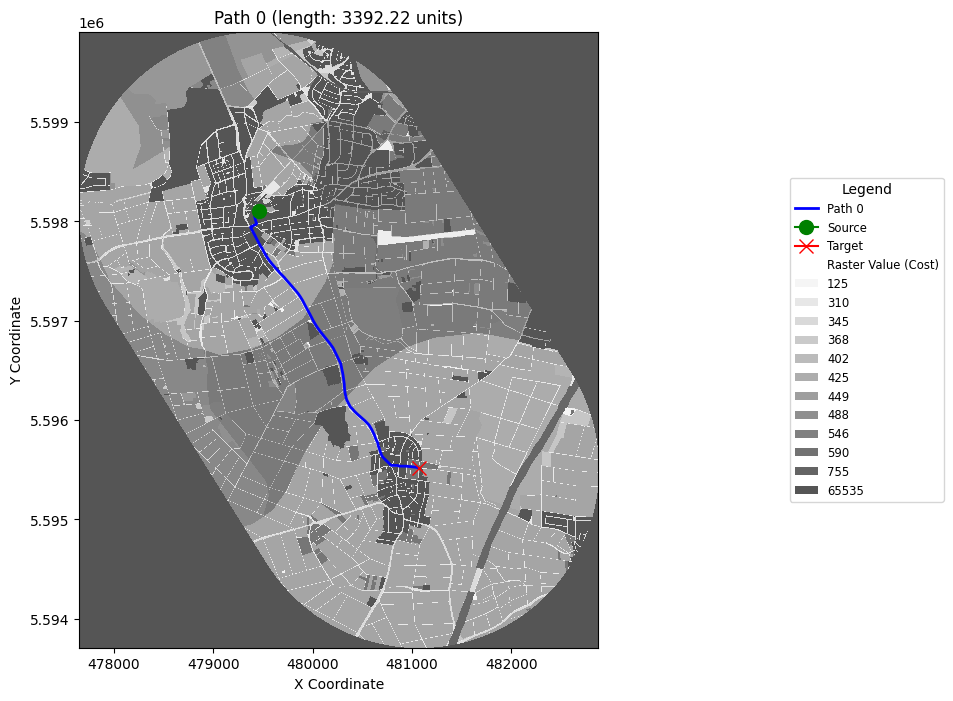

<Axes: title={'center': 'Path 0 (length: 3392.22 units)'}, xlabel='X Coordinate', ylabel='Y Coordinate'>

In [57]:
path_finder.plot_paths()

In [58]:
print("\n" + "="*60)
print("✅ PATH CALCULATION COMPLETE")
print("="*60)
print(f"🛤️  Optimal path found:")
print(f"   • Path details: {path_finder.paths}")
print("-"*60)


✅ PATH CALCULATION COMPLETE
🛤️  Optimal path found:
   • Path details: PathCollection(paths=[0], count=1)
------------------------------------------------------------


Save the calculated path to a GeoJSON file

In [59]:
path_finder.save_paths(save_result)

In [60]:
print(f"\n💾 Path saved to: {save_result}")
print("="*60)



💾 Path saved to: ./data/shapes/example_path_for_distribution_grid_planning.geojson


### 7. Alternative: Perform All Operations in One Step

For convenience, you can perform all the above operations in a single step without 
saving intermediate raster files. This approach is useful for quick analyses or when 
storage space is limited.

**Note**: This method doesn't save the intermediate raster file, so you won't be able 
to reuse it for multiple path calculations without regenerating it.

In [61]:
print("\n" + "="*60)
print("🚀 PERFORMING ALL-IN-ONE PATH FINDING")
print("="*60)
print("This operation will:")
print("  1. Load base land-use data")
print("  2. Apply all cost assumptions")
print("  3. Apply all modifications")
print("  4. Calculate optimal path")
print("-"*60)


🚀 PERFORMING ALL-IN-ONE PATH FINDING
This operation will:
  1. Load base land-use data
  2. Apply all cost assumptions
  3. Apply all modifications
  4. Calculate optimal path
------------------------------------------------------------


Initialize PathFinder with all parameters for one-step processing

In [62]:
path_finder = PathFinder(
    source_coords=source,
    target_coords=target,
    dataset_source=base_wfs_request,
    cost_assumptions=land_use_costs,
    datasets_to_modify=datasets_to_modify,
    bbox=bbox_tuple
)

Find the optimal route

In [63]:
path_finder.find_route()

Path(id=0, source=(479455, 5598100), target=(481069, 5595515), length_m=3394.98, cost=1150059.52)

In [64]:
print("\n" + "="*60)
print("✅ ALL-IN-ONE CALCULATION COMPLETE")
print("="*60)
print(f"🛤️  Optimal path found:")
print(f"   • Path details: {path_finder.paths}")
print("-"*60)


✅ ALL-IN-ONE CALCULATION COMPLETE
🛤️  Optimal path found:
   • Path details: PathCollection(paths=[0], count=1)
------------------------------------------------------------


Generate visualization of the calculated path

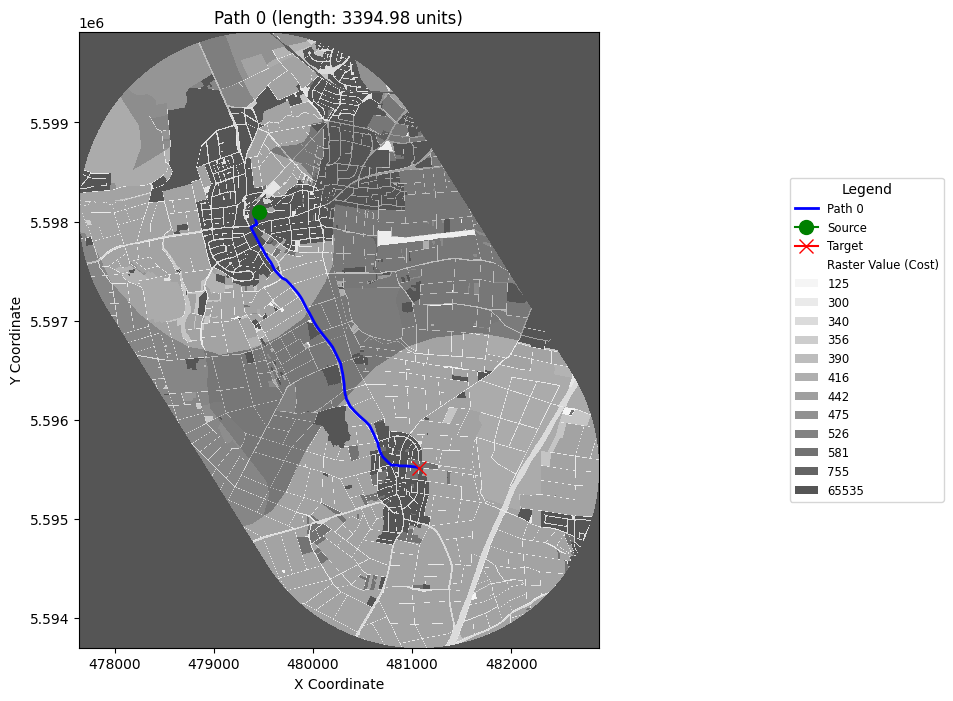

<Axes: title={'center': 'Path 0 (length: 3394.98 units)'}, xlabel='X Coordinate', ylabel='Y Coordinate'>

In [65]:
path_finder.plot_paths()

Save the calculated path to file

In [66]:
path_finder.save_paths(save_result)

In [67]:
print(f"\n💾 Result saved to: {save_result}")
print("\n📌 Note: No intermediate raster file was saved in this approach.")
print("="*60)



💾 Result saved to: ./data/shapes/example_path_for_distribution_grid_planning.geojson

📌 Note: No intermediate raster file was saved in this approach.
